# Одномерное волновое уравнение

Рассматриваем уравнение
$$
u_{tt} = c^2 u_{xx}, \quad x\in[0,L],\ t\ge 0,
$$
и решаем его явной центральной («крест») схемой.

Хотим:
- Проверить сохранение полной энергии 
- Реализовать свободный конец (условие Неймана) при \(x=L:\ u_x(L,t)=0\) и проанализировать отражение волны.
- Смоделировать стоячие волны с модальными начальными условиями \(u(x,0)=\sin(n\pi x/L)\) и \(\sin\big((n+\tfrac12)\pi x/L\big)\).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, Image, display

try:
    from matplotlib.animation import PillowWriter
    HAS_PILLOW = True
except Exception:
    HAS_PILLOW = False

# Область и параметры
L = 1.0
c = 1.0

# Сетка
Nx = 300               
dx = L / Nx
x = np.linspace(0.0, L, Nx + 1)

# Число Куранта
CFL = 0.9                
dt = CFL * dx / c


In [2]:
def triangular_pluck(x, L=1.0, A=1.0):
    '''Треугольный «щипок»: 0 на концах, максимум A в середине L/2.'''
    left = (x <= L/2)
    f = np.empty_like(x)
    f[left] = (2*A/L) * x[left]
    f[~left] = (2*A/L) * (L - x[~left])
    return f

def gaussian(x, x0=0.25, sigma=0.03, amp=1.0):
    '''Гауссов импульс.'''
    return amp * np.exp(-((x - x0)**2) / (2*sigma**2))

def mode_fixed_fixed(x, n=1, L=1.0, amp=1.0):
    '''Мода стоячей волны для краёв «жёстко-жёстко»: sin(n*pi*x/L).'''
    return amp * np.sin(n*np.pi*x/L)

def mode_fixed_free(x, n=0, L=1.0, amp=1.0):
    '''
    Мода стоячей волны для «жёстко-свободно» (Неймана на правом конце):
    sin((n+1/2)*pi*x/L), n = 0,1,2,...
    '''
    return amp * np.sin((n+0.5)*np.pi*x/L)

def right_traveling_pulse_IC(x, f, c, dx):
    '''
    Построение (u0, v0) для примерно право-идущей волны u(x,t) ≈ f(x - c t).
    Д'Аламбер ⇒ берём u_t(x,0) = -c * f'(x).
    '''
    u0 = f.copy()
    df = np.zeros_like(f)
    df[1:-1] = (f[2:] - f[:-2]) / (2*dx)
    df[0] = (f[1] - f[0]) / dx
    df[-1] = (f[-1] - f[-2]) / dx
    v0 = -c * df
    return u0, v0


In [3]:
def simulate_wave(bc='DD', T_final=1.0, CFL=0.9, store_frames=False, frame_cap=160,
                   u0=None, v0=None):
    '''
    Явная центральная схема для одномерного волнового уравнения.
    bc:
        'DD' — закреплённые концы (u(0)=u(L)=0),
        'DN' — слева закреплённый, справа свободный (u(0)=0, u_x(L)=0).
    Возвращает: кадры (если нужно), массив времён, массив энергий, словарь meta.
    Энергия: E(t) = ∫ [u_t^2 + c^2 u_x^2] dx (без множителя 1/2).
    '''
    dt = CFL * dx / c
    lam2 = (c*dt/dx)**2
    n_steps = int(np.ceil(T_final / dt))
    step_skip = max(1, n_steps // frame_cap)

    # Начальные данные
    if u0 is None:
        u_prev = triangular_pluck(x, L=L, A=1.0)
    else:
        u_prev = u0.copy()

    if v0 is None:
        g0 = np.zeros_like(x)  # u_t(x,0)
    else:
        g0 = v0.copy()

    # ГУ для слоя n=0
    if bc == 'DD':
        u_prev[0] = 0.0
        u_prev[-1] = 0.0
    elif bc == 'DN':
        u_prev[0] = 0.0
        u_prev[-1] = u_prev[-2]
    else:
        raise ValueError("bc must be 'DD' or 'DN'")

    # Стартовый шаг (n=1) по Тейлору
    u_curr = u_prev.copy()
    uxx0 = np.zeros_like(u_prev)
    uxx0[1:-1] = (u_prev[2:] - 2*u_prev[1:-1] + u_prev[:-2]) / dx**2
    if bc == 'DN':
        # аппроксимация u_xx на свободном конце
        uxx0[-1] = 2*(u_prev[-2] - u_prev[-1]) / dx**2

    u_curr[1:-1] = u_prev[1:-1] + dt * g0[1:-1] + 0.5 * (c**2) * (dt**2) * uxx0[1:-1]
    if bc == 'DD':
        u_curr[0] = 0.0
        u_curr[-1] = 0.0
    elif bc == 'DN':
        u_curr[-1] = u_prev[-1] + dt * g0[-1] + 0.5 * (c**2) * (dt**2) * uxx0[-1]
        # жёстко обеспечиваем u_x(L)=0
        u_curr[-1] = u_curr[-2]

    frames = [u_prev.copy()] if store_frames else None
    times = []    # ВРЕМЕНА ТОЛЬКО ДЛЯ ЭНЕРГИИ
    energy = []

    def compute_energy(u_n, u_nm1):
        ut = (u_n - u_nm1) / dt        # приблизительно u_t
        ux = (u_n[1:] - u_n[:-1]) / dx # приблизительно u_x
        E = np.sum(ut**2) * dx + (c**2) * np.sum(ux**2) * dx
        return float(E)

    # энергия после первого шага (t = dt)
    t = dt
    energy.append(compute_energy(u_curr, u_prev))
    times.append(t)
    if store_frames and n_steps > 1:
        frames.append(u_curr.copy())

    # Основной цикл по времени: n = 1..n_steps-1
    for n in range(1, n_steps):
        u_next = np.empty_like(u_curr)

        # внутренние точки
        u_next[1:-1] = (2*u_curr[1:-1] - u_prev[1:-1]
                        + lam2 * (u_curr[2:] - 2*u_curr[1:-1] + u_curr[:-2]))

        # граничные точки
        if bc == 'DD':
            u_next[0] = 0.0
            u_next[-1] = 0.0
        elif bc == 'DN':
            u_next[0] = 0.0
            # условие Неймана через «призрачную» точку
            u_next[-1] = (2*u_curr[-1] - u_prev[-1]
                          + lam2 * (u_curr[-2] - 2*u_curr[-1] + u_curr[-2]))
            u_next[-1] = u_next[-2]

        # время и энергия на шаге n+1
        t += dt
        energy.append(compute_energy(u_next, u_curr))
        times.append(t)

        if store_frames and (n % step_skip == 0):
            frames.append(u_next.copy())

        u_prev, u_curr = u_curr, u_next

    meta = {
        "bc": bc,
        "dt": dt,
        "dx": dx,
        "CFL": CFL,
        "n_steps": n_steps,
        "frames_recorded": (len(frames) if store_frames else 0),
    }
    return (np.array(frames) if store_frames else None), np.array(times), np.array(energy), meta


In [4]:
def make_animation(frames, meta, interval_ms=35, title_prefix="1D wave"):
    '''Создать объект-анимацию по массиву слоёв frames.'''
    fig, ax = plt.subplots(figsize=(7.8, 3.2))
    line, = ax.plot(x, frames[0])
    ax.set_xlim(0.0, L)
    lo = np.percentile(frames, 1.0)
    hi = np.percentile(frames, 99.0)
    pad = 0.05 * max(1.0, (hi - lo))
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("x")
    ax.set_ylabel("u(x,t)")
    ax.set_title(f"{title_prefix} | ГУ={meta['bc']} | CFL={meta['CFL']:.2f}, dx={meta['dx']:.4f}, dt={meta['dt']:.5e}")

    def init():
        line.set_data(x, frames[0])
        return (line,)

    def update(i):
        line.set_data(x, frames[i])
        return (line,)

    anim = animation.FuncAnimation(fig, update, init_func=init,
                                   frames=len(frames), interval=interval_ms, blit=True)
    plt.close(fig)
    return anim

def show_or_save(anim, path_gif="wave.gif", fps=30):
    if HAS_PILLOW:
        try:
            writer = PillowWriter(fps=fps)
            anim.save(path_gif, writer=writer)
            display(Image(filename=path_gif))
            print("GIF сохранён в файл:", path_gif)
            return
        except Exception as e:
            print("Не удалось сохранить GIF:", e)
    display(HTML(anim.to_jshtml()))
    print("Анимация показана как HTML (jshtml).")


## 1) Сохранение энергии (DD vs DN)

Проверим дискретную энергию для закреплённых концов (DD) и для случая «жёстко-свободно» (DN).

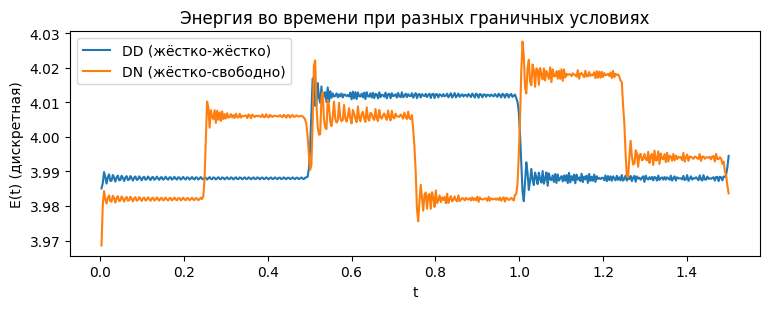

In [5]:
u0 = triangular_pluck(x, L=L, A=1.0)
v0 = np.zeros_like(x)

_, t_DD, E_DD, meta_DD = simulate_wave(bc='DD', T_final=1.5, CFL=0.9,
                                       store_frames=False, u0=u0, v0=v0)
_, t_DN, E_DN, meta_DN = simulate_wave(bc='DN', T_final=1.5, CFL=0.9,
                                       store_frames=False, u0=u0, v0=v0)

plt.figure(figsize=(7.8, 3.2))
plt.plot(t_DD, E_DD, label="DD (жёстко-жёстко)")
plt.plot(t_DN, E_DN, label="DN (жёстко-свободно)")
plt.xlabel("t")
plt.ylabel("E(t) (дискретная)")
plt.title("Энергия во времени при разных граничных условиях")
plt.legend()
plt.tight_layout()
plt.show()


## 2) Отражение от свободного конца для право-идущего импульса

Запускаем вправо гауссов импульс с начальными условиями  
$$ u(x,0)=f(x),\quad u_t(x,0)=-c f'(x) $$

Сравниваем отражение для:
- DD (жёстко-жёстко): волна отражается с сменой знака на правом конце;
- DN (жёстко-свободно): волна отражается без смены знака.

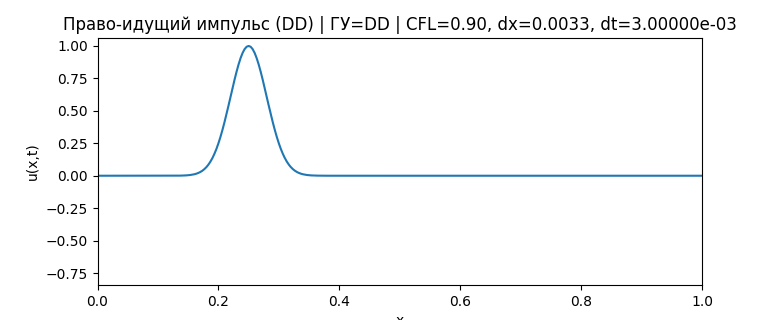

GIF сохранён в файл: pulse_DD.gif


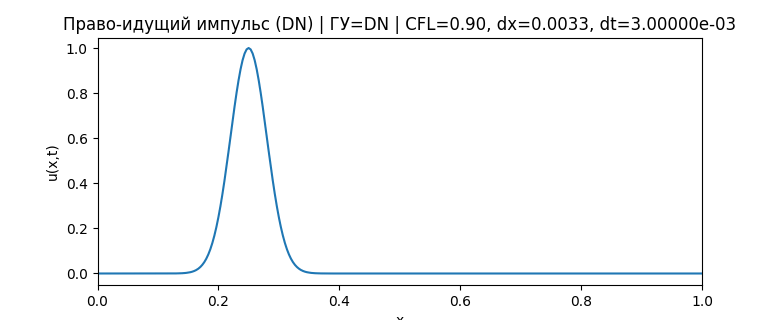

GIF сохранён в файл: pulse_DN.gif


In [6]:
f = gaussian(x, x0=0.25, sigma=0.03, amp=1.0)
u0_pulse, v0_pulse = right_traveling_pulse_IC(x, f, c, dx)

frames_DD_p, t_DD_p, E_DD_p, meta_DD_p = simulate_wave(
    bc='DD', T_final=1.0, CFL=0.9,
    store_frames=True, frame_cap=180,
    u0=u0_pulse, v0=v0_pulse
)

frames_DN_p, t_DN_p, E_DN_p, meta_DN_p = simulate_wave(
    bc='DN', T_final=1.0, CFL=0.9,
    store_frames=True, frame_cap=180,
    u0=u0_pulse, v0=v0_pulse
)

anim_DD = make_animation(frames_DD_p, meta_DD_p,
                         title_prefix="Право-идущий импульс (DD)")
show_or_save(anim_DD, path_gif="pulse_DD.gif", fps=25)

anim_DN = make_animation(frames_DN_p, meta_DN_p,
                         title_prefix="Право-идущий импульс (DN)")
show_or_save(anim_DN, path_gif="pulse_DN.gif", fps=25)


## 3) Стоячие волны (моды)

### Моды для закреплённых концов (DD)

Начальные условия:
$$
u(x,0)=\sin(n\pi x/L),\quad u_t(x,0)=0.
$$
Аналитическое решение:
$$
u(x,t) = \sin(n\pi x/L)\cos(\omega_n t),\quad \omega_n = c\,n\pi/L.
$$

### Моды для «жёстко-свободно» (DN)

Начальные условия:
$$
u(x,0)=\sin\big((n+\tfrac12)\pi x/L\big),\quad u_t(x,0)=0.
$$
Частоты:
$$
\omega_n = c\,(n+\tfrac12)\pi/L,\quad n=0,1,2,\dots
$$

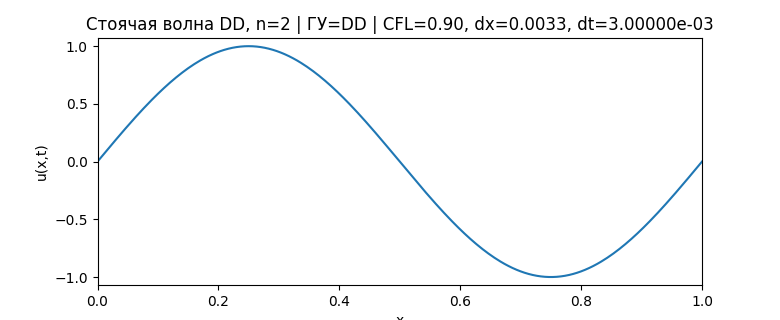

GIF сохранён в файл: standing_DD_n2.gif


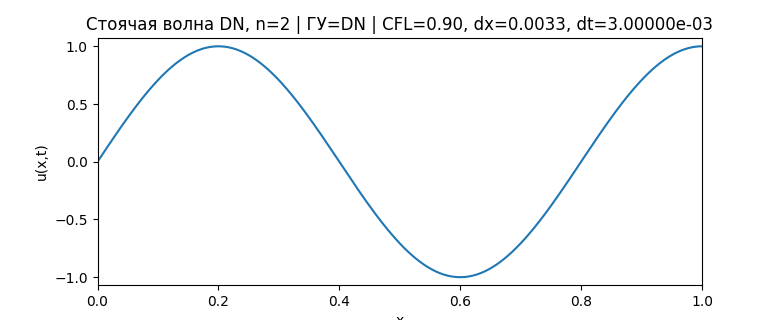

GIF сохранён в файл: standing_DN_n2.gif


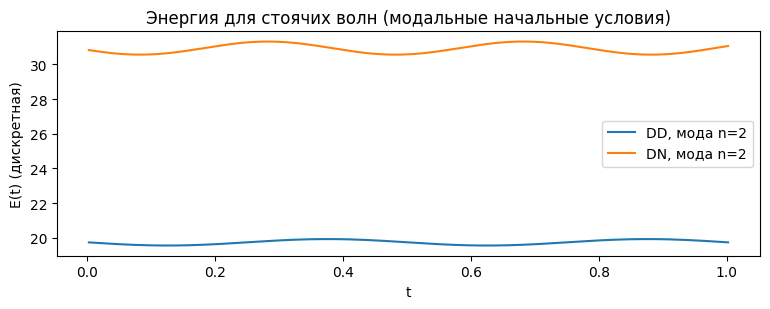

In [7]:
# Мода для DD (жёстко-жёстко)
n_mode = 2
u0_mode_DD = mode_fixed_fixed(x, n=n_mode, L=L, amp=1.0)
v0_mode = np.zeros_like(x)

frames_DD_m, t_DD_m, E_DD_m, meta_DD_m = simulate_wave(
    bc='DD', T_final=1.0, CFL=0.9,
    store_frames=True, frame_cap=160,
    u0=u0_mode_DD, v0=v0_mode
)

anim_DD_m = make_animation(frames_DD_m, meta_DD_m,
                           title_prefix=f"Стоячая волна DD, n={n_mode}")
show_or_save(anim_DD_m, path_gif=f"standing_DD_n{n_mode}.gif", fps=25)

# Мода для DN (жёстко-свободно)
n_mode_DN = 2
u0_mode_DN = mode_fixed_free(x, n=n_mode_DN, L=L, amp=1.0)

frames_DN_m, t_DN_m, E_DN_m, meta_DN_m = simulate_wave(
    bc='DN', T_final=1.0, CFL=0.9,
    store_frames=True, frame_cap=160,
    u0=u0_mode_DN, v0=v0_mode
)

anim_DN_m = make_animation(frames_DN_m, meta_DN_m,
                           title_prefix=f"Стоячая волна DN, n={n_mode_DN}")
show_or_save(anim_DN_m, path_gif=f"standing_DN_n{n_mode_DN}.gif", fps=25)

# Сравнение энергии для мод
plt.figure(figsize=(7.8, 3.2))
plt.plot(t_DD_m, E_DD_m, label=f"DD, мода n={n_mode}")
plt.plot(t_DN_m, E_DN_m, label=f"DN, мода n={n_mode_DN}")
plt.xlabel("t")
plt.ylabel("E(t) (дискретная)")
plt.title("Энергия для стоячих волн (модальные начальные условия)")
plt.legend()
plt.tight_layout()
plt.show()
